In [2]:
import os
import numpy as np
file_dir = 'sub001/ses-04/sub001-ses04-block2-game2_000.npy'
#file_dir = 'thinker-20251223-140527-3152768-0/video_stat.npy'
#file_dir = 'spaceinvaders_4e6_sub1_game2_day3_block2_block-24365/video_stat.npy'
data_dir = os.path.join('./test', file_dir)
data = (np.load(data_dir, allow_pickle=True)).item()
print('data.keys():', data.keys())
print('tree_reps.keys():', data['tree_reps'].keys())

data.keys(): dict_keys(['tree_reps', 'thinker_action', 'human_action', 'status', 'actor_policy', 'step_times', 'env_return'])
tree_reps.keys(): dict_keys(['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq'])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

status = np.asarray(data["status"]).reshape(-1)
cur_rewards = np.asarray(data["env_return"])  # flatten 하지 않음

# step당 1개 y값 만들기
if cur_rewards.ndim == 1:
    y = cur_rewards
else:
    y = cur_rewards.reshape(cur_rewards.shape[0], -1)[:, 0]

# real step의 "원본 인덱스"
real_idx = np.where(status == 0)[0]

# x축: real indices, y축: 해당 cur_rewards
x = np.arange(len(real_idx))
y_plot = y[real_idx]

plt.figure(figsize=(12, 4))
plt.plot(x, y_plot, linewidth=1)
plt.xlabel("step (real indices)")
plt.ylabel("cur_rewards")
plt.title("cur_rewards vs real-step indices")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Found 7 files under test (subXXX only)
After filter: 4 files

== SUBJECT: sub001 ==

[delta_q]
  NOOP:    n=8710 mean=0.5012 std=1.0900
  NonNOOP: n=15879 mean=0.5144 std=1.1223
  Mann-Whitney U p=0.674 (ns)

[delta_v]
  NOOP:    n=8684 mean=0.0598 std=0.0806
  NonNOOP: n=15834 mean=0.0592 std=0.0716
  Mann-Whitney U p=4.8e-06 (***)

[H_all]
  NOOP:    n=8710 mean=1.6204 std=0.1539
  NonNOOP: n=15879 mean=1.6251 std=0.1600
  Mann-Whitney U p=0.0226 (*)

[p_noop]
  NOOP:    n=8710 mean=0.1870 std=0.0902
  NonNOOP: n=15879 mean=0.1618 std=0.0480
  Mann-Whitney U p=9.67e-99 (***)

[V_prev(cur_v)]
  NOOP:    n=8710 mean=2.5739 std=1.1497
  NonNOOP: n=15879 mean=2.7500 std=1.0573
  Mann-Whitney U p=1.46e-28 (***)

[vre]
  NOOP:    n=8706 mean=-0.2150 std=1.2324
  NonNOOP: n=15879 mean=-0.4758 std=1.5264
  Mann-Whitney U p=3.67e-43 (***)

[vre_abs_q]
  NOOP:    n=8706 mean=0.5265 std=1.1349
  NonNOOP: n=15879 mean=0.8147 std=1.3758
  Mann-Whitney U p=1.3e-70 (***)

[vre_abs_v]
  NOOP:    n=6

/tmp/ipykernel_93316/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_93316/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_93316/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_93316/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

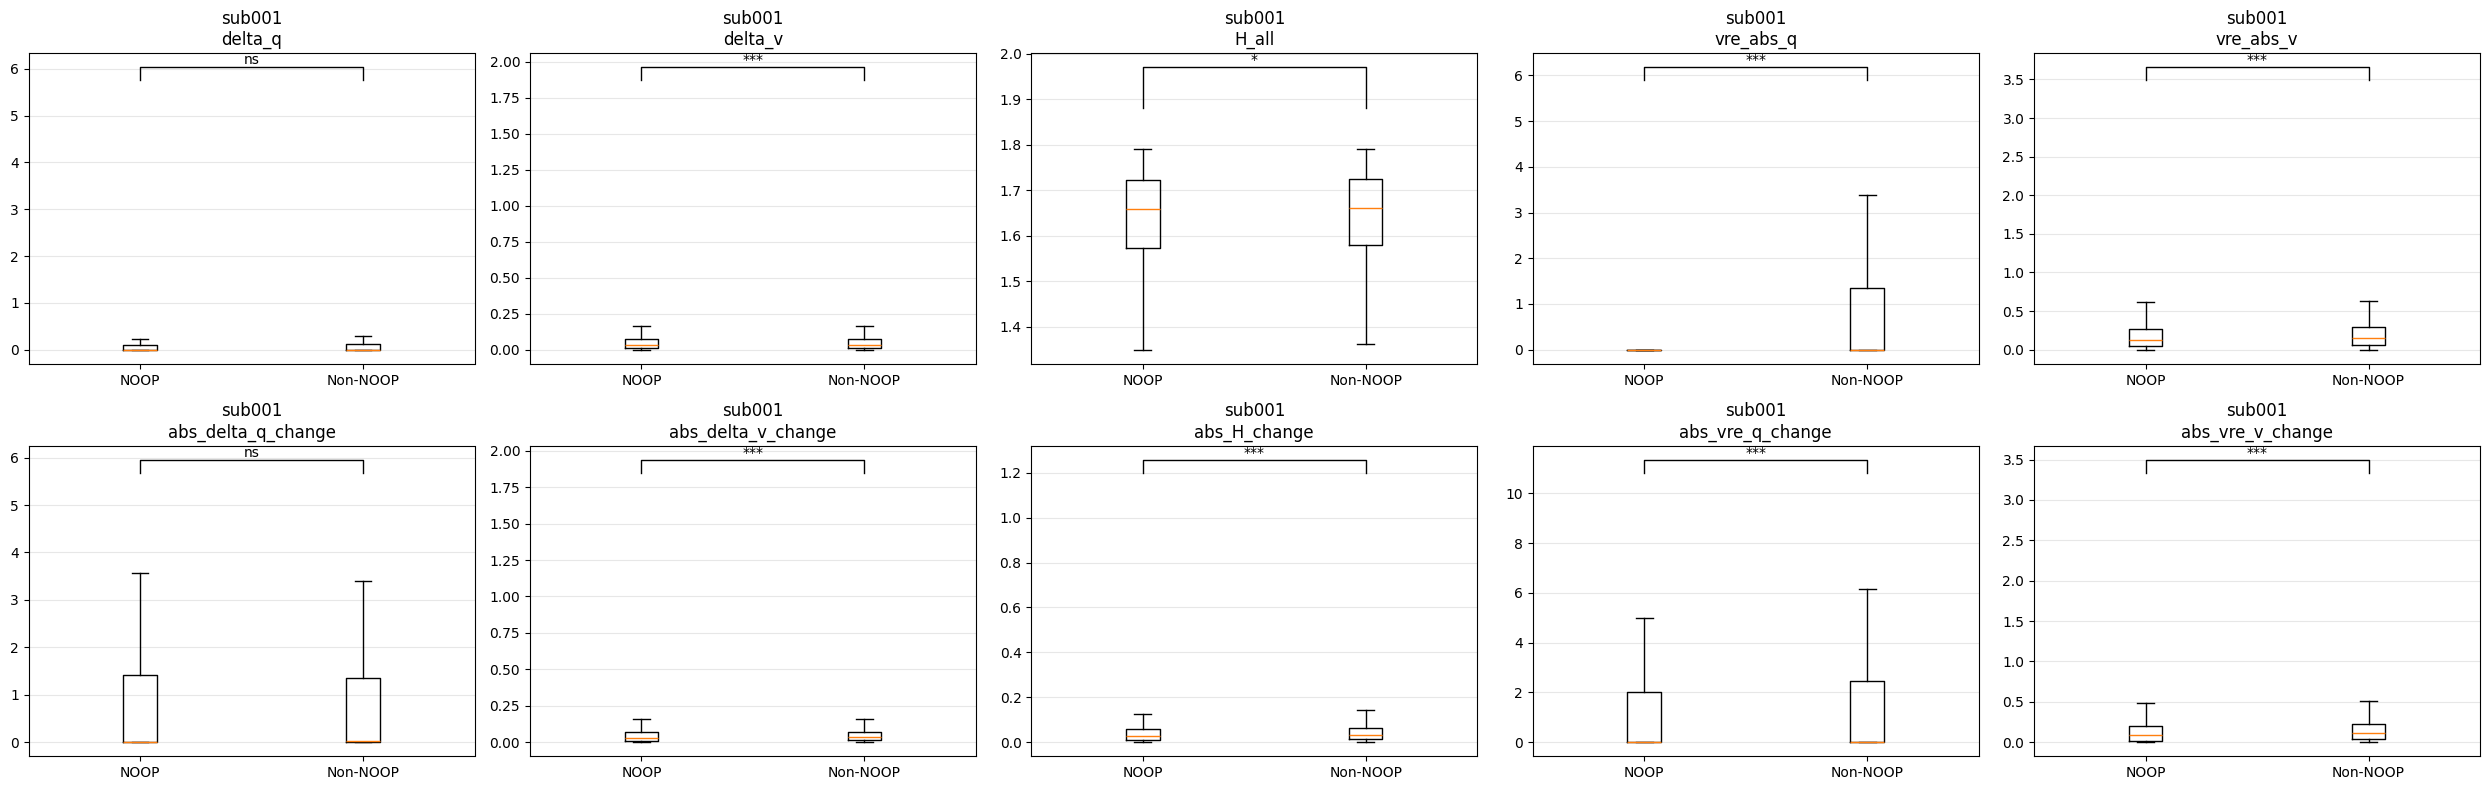

In [22]:
import re
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

# ---- 필터링 옵션 (None이면 전체 포함) ----
FILTER_SUB = "sub001"   # 예: "sub002"
FILTER_SES = "04"       # 예: "03" 또는 "3"
FILTER_BLOCK = None     # 예: "7"
FILTER_GAME = None      # 예: "2"
FILTER_SUFFIX = None    # 예: "000"

# 어떤 레벨을 출력할지 (True면 통계 출력 + 플롯 출력)
SHOW_FILE_LEVEL = False
SHOW_SESSION_BLOCK_LEVEL = False
SHOW_SESSION_LEVEL = False
SHOW_SUBJECT_LEVEL = True

# ====== 유틸 ======
def sig_label(p):
    if not np.isfinite(p):
        return "ns"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def parse_meta(path: Path):
    """
    path 예: test/sub002/ses-03/sub002-ses03-block7-game2_000.npy
    """
    sub = path.parts[-3] if len(path.parts) >= 3 else None  # sub002
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None  # ses-03

    base = path.stem  # sub002-ses03-block7-game2_000
    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,          # "sub002"
        "ses": ses_in,          # "03"
        "block": block_in,      # "7"
        "game": game_in,        # "2"
        "suffix": suffix_in,    # "000"
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB)
        and match_filter(meta["ses"], FILTER_SES)
        and match_filter(meta["block"], FILTER_BLOCK)
        and match_filter(meta["game"], FILTER_GAME)
        and match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def to_action_ids(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1)

def compute_metrics(data):
    tree = data["tree_reps"]

    q_key = "cur_qs_mean"
    v_key = "cur_v"
    root_q_key = "root_qs_mean"

    status = np.asarray(data["status"])

    # human_action / thinker_action 각각 분리
    human_action_raw = data.get("human_action", None)
    thinker_action_raw = data.get("thinker_action", None)

    human_action_ids = to_action_ids(human_action_raw)
    thinker_action_ids = to_action_ids(thinker_action_raw)

    # metrics 계산에 쓸 기본 action (human 우선, 없으면 thinker)
    if human_action_ids is not None:
        action_ids = human_action_ids
    elif thinker_action_ids is not None:
        action_ids = thinker_action_ids
    else:
        raise ValueError("No human_action or thinker_action found in data.")

    q_all = np.asarray(tree[q_key])
    v_all = np.asarray(tree[v_key]).reshape(-1)
    root_qs = np.asarray(tree[root_q_key]) if root_q_key in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy

    num_actions = q_all.shape[1]

    real_all = np.where(status == 0)[0]
    imag2_indices = np.where(status == 2)[0]

    prev_imag_all = np.full(real_all.shape[0], -1, dtype=int)
    j = 0
    for i, r in enumerate(real_all):
        while j < len(imag2_indices) and imag2_indices[j] < r:
            j += 1
        prev_imag_all[i] = imag2_indices[j - 1] if j > 0 else -1

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_imag = prev_imag_all[pos_in_real]

    valid = prev_imag >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_imag = prev_imag[valid]

    # decision-time 기준 action들
    real_actions = action_ids[real_indices]
    human_actions = human_action_ids[real_indices] if human_action_ids is not None else None
    thinker_actions = thinker_action_ids[real_indices] if thinker_action_ids is not None else None

    noop_mask = real_actions == 0
    nonnoop_mask = ~noop_mask

    Q_prev = q_all[prev_imag]
    V_prev = v_all[prev_imag]
    logits_prev = logits_all[prev_imag] if logits_all is not None else None

    delta_q = top2_gap(Q_prev)

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    delta_v = np.full(len(pos_in_real), np.nan, dtype=float)
    vre_abs_v = np.full(len(pos_in_real), np.nan, dtype=float)

    if cur_action_id is not None:
        for i, pos in enumerate(pos_in_real):
            prev_real_idx = real_all[pos - 1]
            last_imag_idx = prev_imag[i]
            if last_imag_idx <= prev_real_idx:
                continue

            idx_range = np.arange(prev_real_idx + 1, last_imag_idx + 1)
            if len(idx_range) == 0:
                continue

            prev_status = status[idx_range - 1]
            mask = (status[idx_range] == 2) & ((prev_status == 0) | (prev_status == 1))
            sel_idx = idx_range[mask]
            if len(sel_idx) == 0:
                continue

            action_means = []
            action_mean_map = {}
            for a in range(num_actions):
                mask_a = cur_action_id[sel_idx] == a
                if np.any(mask_a):
                    mean_v = np.mean(v_all[sel_idx[mask_a]])
                    action_means.append(mean_v)
                    action_mean_map[a] = mean_v

            if len(action_means) >= 2:
                delta_v[i] = top2_gap_1d(np.array(action_means))

            if root_v_all is not None:
                ra = real_actions[i]
                if ra in action_mean_map:
                    vre_abs_v[i] = np.abs(action_mean_map[ra] - root_v_all[real_indices[i]])

    if logits_prev is not None:
        logits_shift = logits_prev - np.max(logits_prev, axis=1, keepdims=True)
        pi_prev = np.exp(logits_shift)
        pi_prev = pi_prev / np.sum(pi_prev, axis=1, keepdims=True)
        H_all = -np.nansum(pi_prev * np.log(pi_prev + 1e-12), axis=1)
        p_noop = pi_prev[:, 0]
    else:
        H_all = np.full(len(pos_in_real), np.nan, dtype=float)
        p_noop = np.full(len(pos_in_real), np.nan, dtype=float)

    next_real = np.full(pos_in_real.shape[0], -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(pos_in_real.shape[0], np.nan, dtype=float)
    if root_qs is not None:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - root_qs[nr, a]
    else:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    # ---- 전후 변화(절댓값) ----
    n_real = len(real_all)
    delta_q_by_pos = np.full(n_real, np.nan)
    delta_v_by_pos = np.full(n_real, np.nan)
    H_by_pos = np.full(n_real, np.nan)
    vre_by_pos = np.full(n_real, np.nan)
    vre_v_by_pos = np.full(n_real, np.nan)

    delta_q_by_pos[pos_in_real] = delta_q
    delta_v_by_pos[pos_in_real] = delta_v
    H_by_pos[pos_in_real] = H_all
    vre_by_pos[pos_in_real] = vre
    vre_v_by_pos[pos_in_real] = vre_abs_v

    next_pos = pos_in_real + 1
    valid_diff = next_pos < n_real

    diff_delta_q = np.full(pos_in_real.shape[0], np.nan)
    diff_delta_v = np.full(pos_in_real.shape[0], np.nan)
    diff_H = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_q = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_v = np.full(pos_in_real.shape[0], np.nan)

    pos_valid = pos_in_real[valid_diff]
    next_valid = next_pos[valid_diff]

    mask_q = np.isfinite(delta_q_by_pos[pos_valid]) & np.isfinite(delta_q_by_pos[next_valid])
    mask_vv = np.isfinite(delta_v_by_pos[pos_valid]) & np.isfinite(delta_v_by_pos[next_valid])
    mask_H = np.isfinite(H_by_pos[pos_valid]) & np.isfinite(H_by_pos[next_valid])
    mask_vre_q = np.isfinite(vre_by_pos[pos_valid]) & np.isfinite(vre_by_pos[next_valid])
    mask_vre_v = np.isfinite(vre_v_by_pos[pos_valid]) & np.isfinite(vre_v_by_pos[next_valid])

    diff_delta_q[np.where(valid_diff)[0][mask_q]] = np.abs(
        delta_q_by_pos[pos_valid[mask_q]] - delta_q_by_pos[next_valid[mask_q]]
    )
    diff_delta_v[np.where(valid_diff)[0][mask_vv]] = np.abs(
        delta_v_by_pos[pos_valid[mask_vv]] - delta_v_by_pos[next_valid[mask_vv]]
    )
    diff_H[np.where(valid_diff)[0][mask_H]] = np.abs(
        H_by_pos[pos_valid[mask_H]] - H_by_pos[next_valid[mask_H]]
    )
    diff_vre_q[np.where(valid_diff)[0][mask_vre_q]] = np.abs(
        vre_by_pos[pos_valid[mask_vre_q]] - vre_by_pos[next_valid[mask_vre_q]]
    )
    diff_vre_v[np.where(valid_diff)[0][mask_vre_v]] = np.abs(
        vre_v_by_pos[pos_valid[mask_vre_v]] - vre_v_by_pos[next_valid[mask_vre_v]]
    )

    metrics.update({
        "abs_delta_q_change": diff_delta_q,
        "abs_delta_v_change": diff_delta_v,
        "abs_H_change": diff_H,
        "abs_vre_q_change": diff_vre_q,
        "abs_vre_v_change": diff_vre_v,
    })

    return metrics, noop_mask, nonnoop_mask, human_actions, thinker_actions

def summarize_arrays(name, a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    print(f"\n[{name}]")
    print(f"  NOOP:    n={len(a)} mean={np.mean(a):.4f} std={np.std(a):.4f}")
    print(f"  NonNOOP: n={len(b)} mean={np.mean(b):.4f} std={np.std(b):.4f}")
    p = np.nan
    if len(a) > 1 and len(b) > 1:
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  Mann-Whitney U p={p:.3g} ({sig_label(p)})")
    return p

def boxplot_metrics(group_name, metrics_store, pvals_store):
    plot_names = [
        "delta_q", "delta_v", "H_all", "vre_abs_q", "vre_abs_v",
        "abs_delta_q_change", "abs_delta_v_change", "abs_H_change",
        "abs_vre_q_change", "abs_vre_v_change",
    ]
    fig, axes = plt.subplots(2, 5, figsize=(5 * 5, 4 * 2))
    axes = axes.flatten()

    for ax, name in zip(axes, plot_names):
        if name not in metrics_store:
            ax.axis("off")
            continue
        a = metrics_store[name]["noop"]
        b = metrics_store[name]["nonnoop"]
        ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
        ax.set_title(f"{group_name}\n{name}")
        ax.grid(axis="y", alpha=0.3)

        p = pvals_store.get(name, np.nan)
        sig = sig_label(p)
        if len(a) > 0 and len(b) > 0 and np.isfinite(p):
            y_max = np.nanmax(np.concatenate([a, b]))
            y = y_max + (0.05 * y_max if y_max != 0 else 0.05)
            h = (0.05 * y_max if y_max != 0 else 0.05)
            ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.0, c="black")
            ax.text(1.5, y + h, sig, ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# ====== 파일 로드 (subXXX 폴더만 스캔) ======
sub_dirs = [
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and re.fullmatch(r"sub\d+", d.name)
]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))

files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

records = []
for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue
    data = np.load(f, allow_pickle=True).item()
    metrics, noop_mask, nonnoop_mask, human_actions, thinker_actions = compute_metrics(data)
    records.append({
        "path": f,
        "meta": meta,
        "metrics": metrics,
        "noop_mask": noop_mask,
        "nonnoop_mask": nonnoop_mask,
        "human_action": human_actions,     # decision-time aligned
        "thinker_action": thinker_actions, # decision-time aligned
    })

print(f"After filter: {len(records)} files")

# ====== 그룹 집계 ======
def init_group_store():
    return {}

def add_to_group(store, group_key, metrics, noop_mask, nonnoop_mask):
    if group_key not in store:
        store[group_key] = {}
    for name, arr in metrics.items():
        if name not in store[group_key]:
            store[group_key][name] = {"noop": [], "nonnoop": []}
        store[group_key][name]["noop"].append(arr[noop_mask & np.isfinite(arr)])
        store[group_key][name]["nonnoop"].append(arr[nonnoop_mask & np.isfinite(arr)])

def finalize_group(store):
    out = {}
    for g, md in store.items():
        out[g] = {}
        for name, parts in md.items():
            a = np.concatenate(parts["noop"]) if len(parts["noop"]) else np.array([])
            b = np.concatenate(parts["nonnoop"]) if len(parts["nonnoop"]) else np.array([])
            out[g][name] = {"noop": a, "nonnoop": b}
    return out

file_store = init_group_store()
sess_block_store = init_group_store()
sess_store = init_group_store()
sub_store = init_group_store()

for r in records:
    m = r["meta"]
    metrics = r["metrics"]
    noop_mask = r["noop_mask"]
    nonnoop_mask = r["nonnoop_mask"]

    file_key = m["basename"]
    sb_key = f"{m['sub']}_ses{m['ses']}_block{m['block']}"
    s_key = f"{m['sub']}_ses{m['ses']}"
    sub_key = f"{m['sub']}"

    add_to_group(file_store, file_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_block_store, sb_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_store, s_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sub_store, sub_key, metrics, noop_mask, nonnoop_mask)

file_store = finalize_group(file_store)
sess_block_store = finalize_group(sess_block_store)
sess_store = finalize_group(sess_store)
sub_store = finalize_group(sub_store)

# ====== 출력 ======
if SHOW_FILE_LEVEL:
    for g, metrics_store in file_store.items():
        print(f"\n== FILE: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_BLOCK_LEVEL:
    for g, metrics_store in sess_block_store.items():
        print(f"\n== SES-BLOCK: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_LEVEL:
    for g, metrics_store in sess_store.items():
        print(f"\n== SESSION: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SUBJECT_LEVEL:
    for g, metrics_store in sub_store.items():
        print(f"\n== SUBJECT: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)


In [ ]:
import re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from IPython.display import display

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm
from statsmodels.othermod.betareg import BetaModel

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

FILTER_SUB = "sub001"
FILTER_SES = "04"
FILTER_BLOCK = None
FILTER_GAME = None
FILTER_SUFFIX = None

RANDOM_STATE = 0
DELTA_V_STATUS = 2  # (하위 호환용 유지)
FRAGMENT_STATUSES = (1, 2)  # imagination fragment 분할에 사용할 status (전체 imagination)

# DBSCAN 설정 (t-SNE 좌표 기준)
DBSCAN_EPS = 1.2
DBSCAN_MIN_SAMPLES = 10
DBSCAN_METRIC = "euclidean"
INCLUDE_NOISE_IN_ANALYSIS = False  # True면 -1(noise)도 boxplot/beta 분석에 포함

# t-SNE 설정
TSNE_PERPLEXITY = 50

# 박스플롯 유의성(별표) 설정
SIG_ALPHA = 0.05
SIG_CORRECTION = "fdr_bh"  # 'bonferroni', 'holm', 'fdr_bh' 등
SHOW_NS_IN_BOX = False
SHOW_GLOBAL_KRUSKAL_IN_TITLE = True
PRINT_PAIRWISE_P_TABLE = True

# tree_reps 키 목록
TREE_KEYS = [
    "root_action", "root_r", "root_d", "root_v", "root_policy",
    "root_qs_mean", "root_qs_max", "root_ns", "root_trail_r",
    "rollout_return", "max_rollout_return", "root_raw_action",
    "cur_action", "cur_r", "cur_d", "cur_v", "cur_policy",
    "cur_qs_mean", "cur_qs_max", "cur_ns", "cur_raw_action",
    "cur_reset", "k", "deprec", "action_seq",
]

# 베타 회귀 설명변수 (p_noop 제외)
REG_COLS = [
    "delta_q",
    "delta_v",
    "H_all",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
]

# 박스플롯 비교 지표 (H_all 포함)
BOX_COLS = [
    "delta_q",
    "delta_v",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
    "H_all",
    "p_noop",
]

# ====== 유틸 ======
def _clean(x):
    return None if x is None else str(x).strip()

FILTER_SUB = _clean(FILTER_SUB)
FILTER_SES = _clean(FILTER_SES)
FILTER_BLOCK = _clean(FILTER_BLOCK)
FILTER_GAME = _clean(FILTER_GAME)
FILTER_SUFFIX = _clean(FILTER_SUFFIX)

def parse_meta(path: Path):
    sub = path.parts[-3] if len(path.parts) >= 3 else None
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None

    base = path.stem

    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,
        "ses": ses_in,
        "block": block_in,
        "game": game_in,
        "suffix": suffix_in,
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB)
        and match_filter(meta["ses"], FILTER_SES)
        and match_filter(meta["block"], FILTER_BLOCK)
        and match_filter(meta["game"], FILTER_GAME)
        and match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def top2_gap_rowwise_ignore_nan(mat):
    out = np.full(mat.shape[0], np.nan, dtype=float)
    for i in range(mat.shape[0]):
        vals = mat[i, np.isfinite(mat[i])]
        if len(vals) >= 2:
            out[i] = top2_gap_1d(vals)
    return out

def to_action_ids(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1)

def prev_index_of_status(status_idx, ref_idx):
    if len(status_idx) == 0:
        return np.full(len(ref_idx), -1, dtype=int)
    pos = np.searchsorted(status_idx, ref_idx) - 1
    return np.where(pos >= 0, status_idx[pos], -1)

def as_numeric_1d(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.dtype == object:
        try:
            arr = arr.astype(float)
        except Exception:
            return None
    if not np.issubdtype(arr.dtype, np.number):
        return None
    return np.ravel(arr).astype(float)

def extract_tree_vec(tree, idx, keys):
    out = {}
    for k in keys:
        if k not in tree:
            out[k] = None
            continue
        arr = np.asarray(tree[k])
        if arr.ndim == 0:
            val = arr
        else:
            if idx >= arr.shape[0]:
                out[k] = None
                continue
            val = arr[idx]
        out[k] = as_numeric_1d(val)
    return out

def entropy_from_logits(logits_2d):
    if logits_2d is None:
        return None
    x = np.asarray(logits_2d, dtype=float)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    shift = x - np.max(x, axis=1, keepdims=True)
    p = np.exp(shift)
    denom = np.sum(p, axis=1, keepdims=True)
    denom = np.where(denom <= 0, 1.0, denom)
    p = p / denom
    return -np.nansum(p * np.log(p + 1e-12), axis=1), p

def split_contiguous(indices_1d: np.ndarray):
    if indices_1d.size == 0:
        return []
    cuts = np.where(np.diff(indices_1d) != 1)[0] + 1
    return np.split(indices_1d, cuts)

def cluster_label(cid):
    return "Noise" if cid == -1 else f"C{cid}"

def build_df_real_steps(data):
    tree = data["tree_reps"]

    status = np.asarray(data["status"])
    q_all = np.asarray(tree["cur_qs_mean"])
    v_all = np.asarray(tree["cur_v"]).reshape(-1)
    root_qs = np.asarray(tree["root_qs_mean"]) if "root_qs_mean" in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy.reshape(-1, 1)

    human_action_raw = data.get("human_action", None)
    human_action_ids = to_action_ids(human_action_raw)
    if human_action_raw is None:
        raise ValueError("human_action not found")

    if human_action_raw.ndim == 2:
        human_valid = human_action_raw.sum(axis=1) > 0
    else:
        human_valid = human_action_ids >= 0

    num_actions = q_all.shape[1]

    real_all = np.where(status == 0)[0]
    s2_indices = np.where(status == 2)[0]
    prev_s2_all = prev_index_of_status(s2_indices, real_all)

    s1_indices = np.where(status == 1)[0]
    prev_s1_all = prev_index_of_status(s1_indices, real_all)

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]

    prev_s2 = prev_s2_all[pos_in_real]
    prev_s1 = prev_s1_all[pos_in_real]

    valid = prev_s2 >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_s2 = prev_s2[valid]
    prev_s1 = prev_s1[valid]

    human_action_dec = human_action_ids[real_indices]
    valid_h = human_valid[real_indices]

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    n_rows = len(pos_in_real)
    V_prev = np.full(n_rows, np.nan, dtype=float)
    Q_prev = np.full((n_rows, num_actions), np.nan, dtype=float)
    delta_v = np.full(n_rows, np.nan, dtype=float)
    vre_abs_v = np.full(n_rows, np.nan, dtype=float)

    for i, pos in enumerate(pos_in_real):
        if cur_action_id is None:
            continue

        curr_real_idx = real_indices[i]
        prev_real_idx = real_all[pos - 1]
        target_action = human_action_dec[i]

        if not (0 <= target_action < num_actions):
            continue

        between = np.arange(prev_real_idx + 1, curr_real_idx)
        if between.size == 0:
            continue

        imag_idx = between[np.isin(status[between], FRAGMENT_STATUSES)]
        if imag_idx.size == 0:
            continue

        frags = split_contiguous(imag_idx)

        matched_frags = []
        for frag in frags:
            if frag.size == 0:
                continue
            first_a = cur_action_id[frag[0]]
            if first_a == target_action:
                matched_frags.append(frag)

        if len(matched_frags) == 0:
            continue

        sel_idx = np.concatenate(matched_frags)

        V_prev[i] = np.mean(v_all[sel_idx])
        Q_prev[i, :] = np.mean(q_all[sel_idx, :], axis=0)

        action_means = []
        action_mean_map = {}
        for a in range(num_actions):
            mask_a = cur_action_id[sel_idx] == a
            if np.any(mask_a):
                mean_v = np.mean(v_all[sel_idx[mask_a]])
                action_means.append(mean_v)
                action_mean_map[a] = mean_v

        if len(action_means) >= 2:
            delta_v[i] = top2_gap_1d(np.array(action_means))

        if root_v_all is not None and curr_real_idx < len(root_v_all):
            if target_action in action_mean_map:
                vre_abs_v[i] = np.abs(action_mean_map[target_action] - root_v_all[curr_real_idx])

    delta_q = top2_gap_rowwise_ignore_nan(Q_prev)

    logits_prev = logits_all[prev_s2] if logits_all is not None else None
    if logits_prev is not None:
        H_all, pi_prev = entropy_from_logits(logits_prev)
        if pi_prev.shape[1] > 0:
            p_noop = pi_prev[:, 0]
        else:
            p_noop = np.full(n_rows, np.nan, dtype=float)
    else:
        H_all = np.full(n_rows, np.nan, dtype=float)
        p_noop = np.full(n_rows, np.nan, dtype=float)

    next_real = np.full(n_rows, -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(n_rows, np.nan, dtype=float)
    for i in range(n_rows):
        nr = next_real[i]
        if nr < 0:
            continue
        a = human_action_dec[i]
        if not (0 <= a < num_actions):
            continue
        if not np.isfinite(Q_prev[i, a]):
            continue

        if root_qs is not None and nr < root_qs.shape[0]:
            vre[i] = Q_prev[i, a] - root_qs[nr, a]
        elif nr < q_all.shape[0]:
            vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    df = pd.DataFrame(metrics)
    return df, human_action_dec, valid_h, prev_s2

# ====== 박스플롯 유의성 유틸 ======
def p_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"

def safe_kruskal(groups):
    if len(groups) < 2:
        return np.nan
    try:
        return kruskal(*groups).pvalue
    except Exception:
        return np.nan

def pairwise_mwu_with_correction(groups, group_names, alpha=0.05, method="fdr_bh"):
    pairs = list(combinations(range(len(groups)), 2))
    raw_ps = []
    valid_pairs = []
    for i, j in pairs:
        x, y = groups[i], groups[j]
        if len(x) == 0 or len(y) == 0:
            continue
        try:
            p = mannwhitneyu(x, y, alternative="two-sided").pvalue
        except Exception:
            p = 1.0
        valid_pairs.append((i, j))
        raw_ps.append(p)

    if len(raw_ps) == 0:
        return []

    _, p_adj, _, _ = multipletests(raw_ps, alpha=alpha, method=method)
    results = []
    for (i, j), p_raw, p_corr in zip(valid_pairs, raw_ps, p_adj):
        results.append({
            "i": i,
            "j": j,
            "name_i": group_names[i],
            "name_j": group_names[j],
            "p_raw": float(p_raw),
            "p_adj": float(p_corr),
            "sig": bool(p_corr < alpha),
            "stars": p_to_stars(p_corr),
        })
    return results

def annotate_pairwise_stars(ax, groups, pairwise_results, show_ns=False):
    finite_groups = [g[np.isfinite(g)] for g in groups if len(g) > 0]
    if len(finite_groups) == 0:
        return
    y_max = max(np.max(g) for g in finite_groups)
    y_min = min(np.min(g) for g in finite_groups)
    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    h = 0.03 * y_range
    step = 0.09 * y_range
    y = y_max + 0.06 * y_range

    draw_targets = [r for r in pairwise_results if r["sig"] or show_ns]
    draw_targets = sorted(draw_targets, key=lambda d: (d["j"] - d["i"], d["p_adj"]))

    for r in draw_targets:
        x1, x2 = r["i"] + 1, r["j"] + 1
        label = r["stars"] if r["sig"] else "ns"
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="k")
        ax.text((x1 + x2) / 2, y + h, label, ha="center", va="bottom", fontsize=10)
        y += step

    if len(draw_targets) > 0:
        ax.set_ylim(top=y + 0.05 * y_range)

# ====== beta regression ======
def plot_sig_beta(Xz_vif, y, params, sig_features, title_prefix=""):
    if len(sig_features) == 0:
        print(f"{title_prefix} no significant features")
        return

    rng = np.random.default_rng(0)
    n = len(sig_features)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(sig_features):
        ax = axes[i]
        if feat not in Xz_vif.columns:
            ax.axis("off")
            continue
        x = Xz_vif[feat].values
        yj = y + (rng.random(len(y)) - 0.5) * 0.02
        ax.scatter(x, yj, s=10, alpha=0.35, c="tab:blue")

        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        b0 = params["const"] if "const" in params else 0.0
        b1 = params[feat] if feat in params else 0.0
        eta = b0 + b1 * x_grid
        mu = 1 / (1 + np.exp(-eta))
        ax.plot(x_grid, mu, color="black", lw=2)

        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel(f"{feat} (z)")
        ax.set_ylabel("p_noop")
        ax.set_title(f"{title_prefix}{feat}")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

def run_p_noop_beta(df, title=""):
    if "p_noop" not in df.columns:
        print(f"[{title}] p_noop not found -> skip")
        return

    y = df["p_noop"].values
    X = df[[c for c in REG_COLS if c in df.columns]].copy()

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, ~X.isna().all()]
    X = X.loc[:, X.nunique(dropna=True) > 1]

    if X.shape[1] == 0:
        print(f"\n[{title}] usable rows=0 cols=0")
        print(" -> skip (no usable predictors)")
        return

    mean = X.mean()
    std = X.std(ddof=0)
    good_cols = std > 0
    X = X.loc[:, good_cols]
    Xz = (X - mean[good_cols]) / std[good_cols]

    mask = np.isfinite(Xz).all(axis=1) & np.isfinite(y)
    Xz = Xz[mask].reset_index(drop=True)
    y = y[mask]
    y = np.clip(y, 1e-4, 1 - 1e-4)

    print(f"\n[{title}] usable rows={len(y)} cols={Xz.shape[1]}")
    if len(y) == 0 or Xz.shape[1] == 0:
        print(" -> skip (no usable data)")
        return

    Xz_const = sm.add_constant(Xz, has_constant="add")
    try:
        res = BetaModel(y, Xz_const).fit(disp=False)
    except Exception as e:
        print("Beta regression failed:", e)
        return

    print(res.summary())
    k = Xz_const.shape[1]
    coef = pd.DataFrame({"coef": res.params[:k], "p": res.pvalues[:k]}, index=Xz_const.columns).sort_values("p")
    display(coef)

    sig = coef[(coef["p"] < 0.05) & (coef.index != "const")]
    sig_cols = [c for c in sig.index if c != "const"]
    plot_sig_beta(Xz, y, res.params, sig_cols, title_prefix=f"{title} | ")

# ====== 데이터 로드 ======
sub_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir() and re.fullmatch(r"sub\d+", d.name)]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))
files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

print("Discovered file list:")
if len(files) == 0:
    print(" - (none)")
else:
    for i, f in enumerate(files, 1):
        print(f" {i:02d}. {f}")

samples = []
filtered_files = []
used_files = []
used_file_noop_count = {}

for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue

    filtered_files.append(str(f))
    sample_count_before_file = len(samples)

    data = np.load(f, allow_pickle=True).item()
    df, human_action_dec, valid_h, prev_s2 = build_df_real_steps(data)

    df = df.loc[valid_h].reset_index(drop=True)
    human_action_dec = human_action_dec[valid_h]
    prev_s2 = prev_s2[valid_h]
    tree = data["tree_reps"]

    for i in range(len(df)):
        if human_action_dec[i] != 0:
            continue
        tree_vec = extract_tree_vec(tree, prev_s2[i], TREE_KEYS)
        samples.append({"row": df.iloc[i].to_dict(), "tree_vec": tree_vec})

    added_noop = len(samples) - sample_count_before_file
    if added_noop > 0:
        used_files.append(str(f))
        used_file_noop_count[str(f)] = added_noop

print(f"\nFiles passing filters (sub/ses/block/game/suffix): {len(filtered_files)}")
if len(filtered_files) == 0:
    print(" - (none)")
else:
    for i, fp in enumerate(filtered_files, 1):
        print(f" {i:02d}. {fp}")

print(f"\nFiles used for NOOP analysis: {len(used_files)}")
if len(used_files) == 0:
    print(" - (none)")
else:
    for i, fp in enumerate(used_files, 1):
        print(f" {i:02d}. {fp} (noop_samples={used_file_noop_count[fp]})")

if len(samples) == 0:
    raise RuntimeError("NOOP 데이터가 없습니다.")

# ====== tree_reps 키 중 일관된 것만 유지 ======
size_map = {k: set() for k in TREE_KEYS}
for s in samples:
    for k in TREE_KEYS:
        v = s["tree_vec"].get(k)
        if v is None:
            size_map[k].add(None)
        else:
            size_map[k].add(len(v))

keep_keys = [k for k, sizes in size_map.items() if (None not in sizes and len(sizes) == 1)]
drop_keys = [k for k in TREE_KEYS if k not in keep_keys]

print(f"Kept keys ({len(keep_keys)}): {keep_keys}")
print(f"Dropped keys ({len(drop_keys)}): {drop_keys}")

# ====== X + df_noop 구성 ======
X_rows, rows = [], []
for s in samples:
    vec = s["tree_vec"]
    if all(vec[k] is not None for k in keep_keys):
        X_rows.append(np.concatenate([vec[k] for k in keep_keys]))
        rows.append(s["row"])

if len(X_rows) == 0:
    raise RuntimeError("유효한 feature 벡터가 없습니다.")

X = np.vstack(X_rows)
df_noop = pd.DataFrame(rows)

# 표준화
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# ====== t-SNE 변환 ======
n_samples = Xz.shape[0]
if n_samples < 3:
    raise RuntimeError("t-SNE 변환을 위해 최소 3개 샘플이 필요합니다.")

tsne_perplexity = min(TSNE_PERPLEXITY, n_samples - 1)
if tsne_perplexity < 2:
    tsne_perplexity = 2

tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    init="pca",
    random_state=RANDOM_STATE,
)
X2 = tsne.fit_transform(Xz)
print(f"t-SNE perplexity used: {tsne_perplexity} (n_samples={n_samples})")

# ====== DBSCAN 클러스터링 (t-SNE 좌표 기준) ======
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric=DBSCAN_METRIC,
)
labels = dbscan.fit_predict(X2)
df_noop["cluster"] = labels

unique_labels, counts = np.unique(labels, return_counts=True)
cluster_count_map = dict(zip(unique_labels.tolist(), counts.tolist()))
noise_count = cluster_count_map.get(-1, 0)
core_cluster_ids = sorted([cid for cid in unique_labels.tolist() if cid != -1])

print("Cluster counts (label -> n):", cluster_count_map)
print(f"Found clusters (excluding noise): {len(core_cluster_ids)}")
print(f"Noise samples (-1): {noise_count}")

analysis_cluster_ids = core_cluster_ids.copy()
if INCLUDE_NOISE_IN_ANALYSIS and (-1 in unique_labels):
    analysis_cluster_ids = [-1] + analysis_cluster_ids

# H_all 유효 샘플 체크
if "H_all" in df_noop.columns:
    print(f"H_all finite rows: {np.isfinite(df_noop['H_all']).sum()} / {len(df_noop)}")

# ====== t-SNE 시각화 ======
cluster_ids_plot = sorted(np.unique(labels).tolist())
non_noise_ids = [cid for cid in cluster_ids_plot if cid != -1]

cmap = plt.get_cmap("rainbow", max(1, len(non_noise_ids)))
cluster_to_color = {}
for i, cid in enumerate(non_noise_ids):
    cluster_to_color[cid] = cmap(i)
cluster_to_color[-1] = (0.6, 0.6, 0.6, 0.8)  # noise는 회색

point_colors = [cluster_to_color.get(cid, (0, 0, 0, 1)) for cid in labels]

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=point_colors, s=10, alpha=0.75)
plt.title("NOOP Clusters (t-SNE 2D) - Raw tree_reps [DBSCAN]")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# ====== 박스플롯: cluster별 요약 지표 + 유의성 별표 ======
use_cols = [c for c in BOX_COLS if c in df_noop.columns]
if len(use_cols) == 0:
    print("BOX_COLS 중 사용 가능한 컬럼이 없습니다.")
elif len(analysis_cluster_ids) == 0:
    print("분석 가능한 클러스터가 없습니다. (모든 샘플이 noise일 수 있음)")
else:
    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(use_cols):
        ax = axes[i]
        group_data, group_names = [], []

        for cid in analysis_cluster_ids:
            vals = df_noop.loc[df_noop["cluster"] == cid, col].values
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                group_data.append(vals)
                group_names.append(cluster_label(cid))

        if len(group_data) == 0:
            ax.axis("off")
            continue

        ax.boxplot(group_data, labels=group_names, showfliers=False)
        ax.grid(axis="y", alpha=0.3)

        global_p = safe_kruskal(group_data)
        if SHOW_GLOBAL_KRUSKAL_IN_TITLE and np.isfinite(global_p):
            ax.set_title(f"{col}\nKruskal p={global_p:.2e}")
        else:
            ax.set_title(col)

        pairwise_results = pairwise_mwu_with_correction(
            groups=group_data,
            group_names=group_names,
            alpha=SIG_ALPHA,
            method=SIG_CORRECTION,
        )

        annotate_pairwise_stars(
            ax=ax,
            groups=group_data,
            pairwise_results=pairwise_results,
            show_ns=SHOW_NS_IN_BOX,
        )

        if PRINT_PAIRWISE_P_TABLE:
            print(f"\n[{col}] pairwise MWU ({SIG_CORRECTION}, alpha={SIG_ALPHA})")
            if len(pairwise_results) == 0:
                print(" - no valid pairs")
            else:
                for r in pairwise_results:
                    print(
                        f" - {r['name_i']} vs {r['name_j']}: "
                        f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, "
                        f"{'sig' if r['sig'] else 'ns'} {r['stars']}"
                    )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# ====== Cluster별 Beta Regression (p_noop) ======
if len(analysis_cluster_ids) == 0:
    print("Beta regression을 수행할 클러스터가 없습니다.")
else:
    for c in analysis_cluster_ids:
        df_c = df_noop.loc[df_noop["cluster"] == c].reset_index(drop=True)
        title = "NOISE" if c == -1 else f"CLUSTER {c}"
        run_p_noop_beta(df_c, title=title)


In [ ]:
# ====== NOOP 이후 k-step return(뒤 - 앞) 계산 + cluster별 box plot ======
# 이 셀은 앞에서 정의한 함수/변수(parse_meta, passes_filters, prev_index_of_status,
# to_action_ids, extract_tree_vec, files, keep_keys, df_noop, TREE_KEYS 등)를 사용합니다.

K_STEP = 240  # 기본값

def _build_aligned_noop_k_returns(data, k_step=40):
    """
    기존 df_noop 생성 순서와 동일한 샘플 순서로
    각 NOOP 샘플의 k_step_return = env_return[last] - env_return[first] 을 계산해 반환.
    """
    status = np.asarray(data["status"])
    env_return = np.asarray(data["cur_rewards"]).reshape(-1)

    human_action_raw = data.get("human_action", None)
    if human_action_raw is None:
        return []

    human_action_ids = to_action_ids(human_action_raw)
    if human_action_raw.ndim == 2:
        human_valid = human_action_raw.sum(axis=1) > 0
    else:
        human_valid = human_action_ids >= 0

    # build_df_real_steps와 동일 축/정렬
    real_all = np.where(status == 0)[0]
    if len(real_all) <= 1:
        return []

    s2_indices = np.where(status == 2)[0]
    prev_s2_all = prev_index_of_status(s2_indices, real_all)

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_s2 = prev_s2_all[pos_in_real]

    valid = prev_s2 >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_s2 = prev_s2[valid]

    human_action_dec = human_action_ids[real_indices]
    valid_h = human_valid[real_indices]

    real_indices = real_indices[valid_h]
    prev_s2 = prev_s2[valid_h]
    human_action_dec = human_action_dec[valid_h]

    real_pos_lookup = {idx: p for p, idx in enumerate(real_all)}
    tree = data["tree_reps"]

    out = []
    for i in range(len(real_indices)):
        # 기존 df_noop과 동일하게 NOOP만
        if human_action_dec[i] != 0:
            continue

        # 기존 df_noop과 동일하게 keep_keys 유효 샘플만
        vec = extract_tree_vec(tree, prev_s2[i], TREE_KEYS)
        if not all(vec[k] is not None for k in keep_keys):
            continue

        r_idx = real_indices[i]
        if r_idx not in real_pos_lookup:
            continue
        p = real_pos_lookup[r_idx]

        # "그곳부터 k개의 real step"
        end = min(p + k_step, len(real_all))
        sel_real_idx = real_all[p:end]
        if sel_real_idx.size == 0:
            continue

        first_val = env_return[sel_real_idx[0]]
        last_val = env_return[sel_real_idx[-1]]

        # 길이가 1이면 last==first 이므로 0
        k_ret = float(last_val - first_val)
        out.append(k_ret)

    return out


# 1) 파일 전체 순회하며 기존 df_noop 순서와 동일하게 k_step_return 생성
k_step_returns = []
for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue

    data = np.load(f, allow_pickle=True).item()
    k_step_returns.extend(_build_aligned_noop_k_returns(data, k_step=K_STEP))

k_step_returns = np.asarray(k_step_returns, dtype=float)
print(f"k_step_returns built: {len(k_step_returns)}")

# 2) df_noop와 길이 정합 체크 (순서 정합이 핵심)
if len(k_step_returns) != len(df_noop):
    raise RuntimeError(
        f"Length mismatch: k_step_returns={len(k_step_returns)} vs df_noop={len(df_noop)}. "
        "샘플 정렬 조건(필터/keep_keys/NOOP 조건) 확인 필요."
    )

df_noop["k_step_return"] = k_step_returns

# 3) cluster별 box plot + 통계
cluster_ids = sorted(df_noop["cluster"].unique().tolist())
group_data = []
group_names = []

for cid in cluster_ids:
    vals = df_noop.loc[df_noop["cluster"] == cid, "k_step_return"].values
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        group_data.append(vals)
        group_names.append(f"C{cid}")

print("\nCluster-wise k_step_return summary (last - first)")
for name, arr in zip(group_names, group_data):
    q1, med, q3 = np.quantile(arr, [0.25, 0.5, 0.75])
    print(f" - {name}: n={len(arr)}, mean={np.mean(arr):.4f}, med={med:.4f}, IQR=({q1:.4f},{q3:.4f})")

global_p = safe_kruskal(group_data)
print(f"\nKruskal p={global_p:.3e}")

pairwise_results = pairwise_mwu_with_correction(
    groups=group_data,
    group_names=group_names,
    alpha=SIG_ALPHA,
    method=SIG_CORRECTION,
)

print(f"\n[k_step_return] pairwise MWU ({SIG_CORRECTION}, alpha={SIG_ALPHA})")
if len(pairwise_results) == 0:
    print(" - no valid pairs")
else:
    for r in pairwise_results:
        print(
            f" - {r['name_i']} vs {r['name_j']}: "
            f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, "
            f"{'sig' if r['sig'] else 'ns'} {r['stars']}"
        )

plt.figure(figsize=(6.5, 4.8))
ax = plt.gca()
ax.boxplot(group_data, labels=group_names, showfliers=False)
ax.grid(axis="y", alpha=0.3)
ax.set_title(f"k_step_return (K={K_STEP}, last-first)\nKruskal p={global_p:.2e}")
ax.set_ylabel("env_return[last real step] - env_return[first real step]")

annotate_pairwise_stars(
    ax=ax,
    groups=group_data,
    pairwise_results=pairwise_results,
    show_ns=SHOW_NS_IN_BOX,
)

plt.tight_layout()
plt.show()


In [27]:
import numpy as np

def _logsumexp(x, axis=-1, keepdims=False):
    m = np.max(x, axis=axis, keepdims=True)
    y = m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True))
    return y if keepdims else np.squeeze(y, axis=axis)

def _policy_logp_and_p(x):
    x = np.asarray(x)
    T, A = x.shape[0], x.shape[-1]
    if x.ndim == 2:
        maybe_prob = (x.min() >= 0) and (x.max() <= 1) and np.allclose(x.sum(axis=-1), 1.0, atol=1e-3)
        if maybe_prob:
            p = np.clip(x, 1e-12, 1.0)
            p = p / p.sum(axis=-1, keepdims=True)
            return np.log(p), p
        logp = x - _logsumexp(x, axis=-1, keepdims=True)
        return logp, np.exp(logp)
    D = int(np.prod(x.shape[1:-1]))
    x = x.reshape(T, D, A)
    maybe_prob = (x.min() >= 0) and (x.max() <= 1) and np.allclose(x.sum(axis=-1), 1.0, atol=1e-3)
    if maybe_prob:
        p = np.clip(x, 1e-12, 1.0)
        p = p / p.sum(axis=-1, keepdims=True)
    else:
        logp = x - _logsumexp(x, axis=-1, keepdims=True)
        p = np.exp(logp)
    p = p.mean(axis=1)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(np.clip(p, 1e-12, 1.0)), p

def _to_action_and_valid(x):
    x = np.asarray(x)
    if x.ndim == 2:
        a = np.argmax(x, axis=1)
        v = x.sum(axis=1) > 0
        return a.astype(int), v
    a = x.astype(int)
    v = a >= 0
    return a, v

actor_policy = np.asarray(data["actor_policy"])
human_action, human_valid = _to_action_and_valid(data["human_action"])
thinker_action, thinker_valid = _to_action_and_valid(data["thinker_action"])

T = min(actor_policy.shape[0], len(human_action), len(thinker_action))
actor_policy = actor_policy[:T]
human_action = human_action[:T]
thinker_action = thinker_action[:T]
human_valid = human_valid[:T]
thinker_valid = thinker_valid[:T]

logp, probs = _policy_logp_and_p(actor_policy)
A = probs.shape[1]

valid_action_h = (human_action >= 0) & (human_action < A)
valid_action_m = (thinker_action >= 0) & (thinker_action < A)

mask = human_valid & thinker_valid & valid_action_h & valid_action_m
if "status" in data:
    status = np.asarray(data["status"])[:T]
    mask = mask & (status == 0)

idx = np.where(mask)[0]
assert len(idx) > 0

agree_tm = (thinker_action[idx] == human_action[idx]).mean()
argmax_acc = (np.argmax(probs[idx], axis=1) == human_action[idx]).mean()

ll_h = logp[idx, human_action[idx]]
nll_h = -ll_h
ppl_h = float(np.exp(nll_h.mean()))
ea_h = float(probs[idx, human_action[idx]].mean())

ll_m = logp[idx, thinker_action[idx]]
nll_m = -ll_m
ppl_m = float(np.exp(nll_m.mean()))
ea_m = float(probs[idx, thinker_action[idx]].mean())

nll_uniform = float(np.log(A))
ppl_uniform = float(A)
delta_nll_vs_uniform = float(nll_uniform - nll_h.mean())

print("N samples:", len(idx))
print("A (action space):", A)
print("thinker-human agreement:", float(agree_tm))
print("policy argmax-human accuracy:", float(argmax_acc))

print("human mean log-likelihood:", float(ll_h.mean()))
print("human mean NLL:", float(nll_h.mean()))
print("human perplexity:", ppl_h)
print("human expected agreement (E[pi(a_h)]):", ea_h)

print("thinker mean log-likelihood:", float(ll_m.mean()))
print("thinker mean NLL:", float(nll_m.mean()))
print("thinker perplexity:", ppl_m)
print("thinker expected agreement (E[pi(a_m)]):", ea_m)

print("uniform mean NLL (=log A):", nll_uniform)
print("uniform perplexity (=A):", ppl_uniform)
print("delta NLL vs uniform (log A - NLL_h):", delta_nll_vs_uniform)


N samples: 5796
A (action space): 6
thinker-human agreement: 0.24551414768806074
policy argmax-human accuracy: 0.3021048999309869
human mean log-likelihood: -1.5355063676834106
human mean NLL: 1.5355063676834106
human perplexity: 4.643676280975342
human expected agreement (E[pi(a_h)]): 0.23844800889492035
thinker mean log-likelihood: -1.5534448623657227
thinker mean NLL: 1.5534448623657227
thinker perplexity: 4.727728843688965
thinker expected agreement (E[pi(a_m)]): 0.24065154790878296
uniform mean NLL (=log A): 1.791759469228055
uniform perplexity (=A): 6.0
delta NLL vs uniform (log A - NLL_h): 0.2562531015446443
